In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [18]:
BASE_DIR = Path(__file__).parent if '__file__' in dir() else Path.cwd()
df = pd.read_csv(BASE_DIR / 'data' / 'processed_data.csv')
with open(BASE_DIR / 'model' / 'xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)

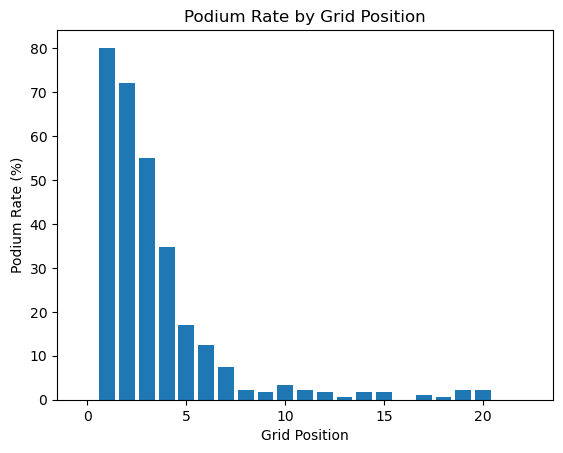

In [19]:
feature_columns = ['GridPosition_race', 'DriverAvgLast3', 'TrackHistoryAvg', 'TeamAvgSeason', 'ChampionshipPos']

### first Chart
podium_rate = df.groupby('GridPosition_race')['Podium'].mean() * 100    

plt.figure()    # to create basic figure
plt.bar(podium_rate.index, podium_rate.values)
plt.xlabel('Grid Position')
plt.ylabel('Podium Rate (%)')
plt.title('Podium Rate by Grid Position')
plt.show()



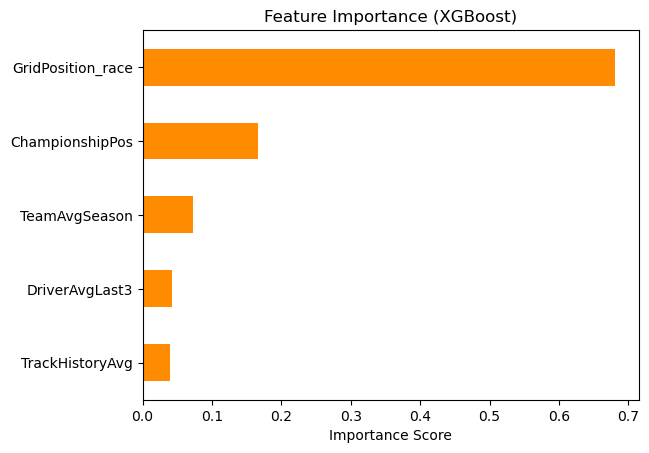

In [20]:
# Series will turn a regular list to labeled list 
# feature importance tells us how important each feature is in the model as percentage
importances = pd.Series(model.feature_importances_, index=feature_columns).sort_values()

plt.figure()
importances.plot(kind='barh', color='darkorange')
plt.xlabel('Importance Score')
plt.title('Feature Importance (XGBoost)')
plt.show()

In [ ]:
# Define features and target variable
X = df[['GridPosition_race', 'DriverAvgLast3', 'TrackHistoryAvg', 'TeamAvgSeason', 'ChampionshipPos']]
y = df['Podium']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.87      0.91       604
           1       0.51      0.79      0.62       102

    accuracy                           0.86       706
   macro avg       0.74      0.83      0.77       706
weighted avg       0.90      0.86      0.87       706

Confusion Matrix:


array([[526,  78],
       [ 21,  81]])

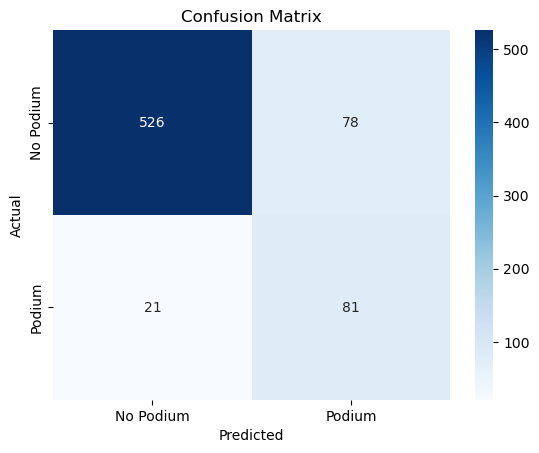

In [32]:
plt.figure()

sns.heatmap(
    confusion_matrix(y_test, y_pred),  # the data
    annot=True,                         # show numbers inside boxes
    fmt='d',                            # format numbers as integers
    cmap = 'Blues',
    xticklabels=['No Podium', 'Podium'], # x axis labels
    yticklabels=['No Podium', 'Podium']  # y axis labels
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()